# Day 2 - H1: Review Drivers

Building on the Day 1 data quality findings, this notebook tests the first of two hypotheses about what drives customer trust loss on the Olist marketplace. The second hypothesis (H2: geographic fault lines) lives in `03_h2_geographic.ipynb`.

## Hypothesis

**H1.** The delivery promise gap (estimated delivery date minus actual delivery date) drives review scores more than product category does. If true, customer satisfaction is primarily a logistics problem, not a product problem.

This notebook includes a falsification test: an analysis whose result would prove H1 wrong rather than only confirming it.

The findings here feed directly into the Day 3 Seller Trust Score.

## DQ findings applied below

Per Day 1's `01_data_quality.ipynb`:

- Use `customer_unique_id` for any per-customer aggregation (not `customer_id`).
- Filter orders to `order_purchase_timestamp` between 2016-09-04 and 2018-10-17.
- Collapse `geolocation` to one row per zip prefix (median lat/lng).
- Tag null product categories as "unknown".
- Treat null `order_delivered_customer_date` as undelivered, not missing data.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.load import load_analysis_df

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
sns.set_palette("Set2")


## Loading the analysis dataframe

DQ-aware data loading lives in `src/load.py`, so every notebook in this project starts from the same prepared data. `load_analysis_df()` returns one row per (order, item) pair with all Day 1 DQ findings applied (operating window filter, null categories tagged as "unknown", geolocation collapsed) and three derived columns: `promise_gap_days`, `actual_delivery_days`, `category_en`.


In [2]:
analysis_df = load_analysis_df()

print(f"analysis_df shape: {analysis_df.shape}")
print(f"rows with reviews:  {analysis_df['review_score'].notna().sum():,} of {len(analysis_df):,} ({analysis_df['review_score'].notna().mean():.1%})")
delivered = analysis_df['order_delivered_customer_date'].notna()
print(f"rows delivered:     {delivered.sum():,} ({delivered.mean():.1%})")


analysis_df shape: (112650, 28)
rows with reviews:  111,708 of 112,650 (99.2%)
rows delivered:     110,196 (97.8%)


## 1. Sanity baseline

Three charts before any hypothesis claim. This will give context for the tests to follow.


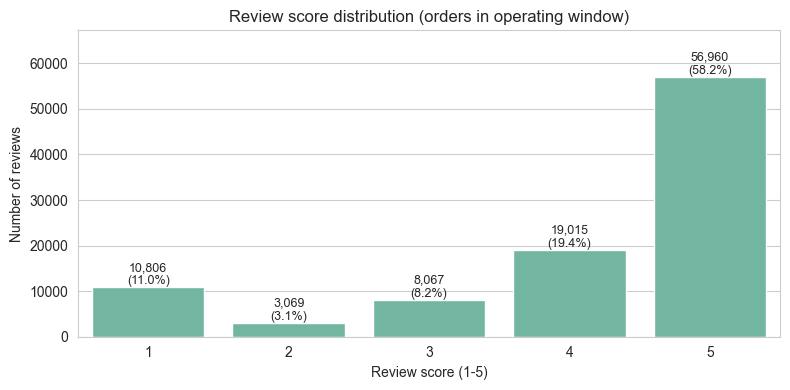

In [3]:
# Per-order review score distribution (one row per order, deduped from analysis_df).
order_level = analysis_df.drop_duplicates("order_id")
review_counts = (order_level["review_score"]
                 .dropna().astype(int)
                 .value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=review_counts.index, y=review_counts.values, ax=ax)
ax.set_xlabel("Review score (1-5)")
ax.set_ylabel("Number of reviews")
ax.set_title("Review score distribution (orders in operating window)")
total = review_counts.sum()
for i, v in enumerate(review_counts.values):
    label = f"{v:,}\n({v/total:.1%})"
    ax.text(i, v, label, ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, review_counts.max() * 1.18)
plt.tight_layout()
plt.show()


**Review distribution.** Strongly U-shaped. 5-star reviews dominate at 58.2%, but 1-star is the second most common at 11.0%, more than 3-star (8.2%) or 2-star (3.1%). 4-star fills out the rest at 19.4%. People who write reviews tend to be at the extremes: very satisfied or very upset. Middle-of-the-road experiences mostly go unreviewed. This shape makes 1-star reviews a meaningful and noisy signal of trust loss, which is what the hypothesis tests below will exploit.


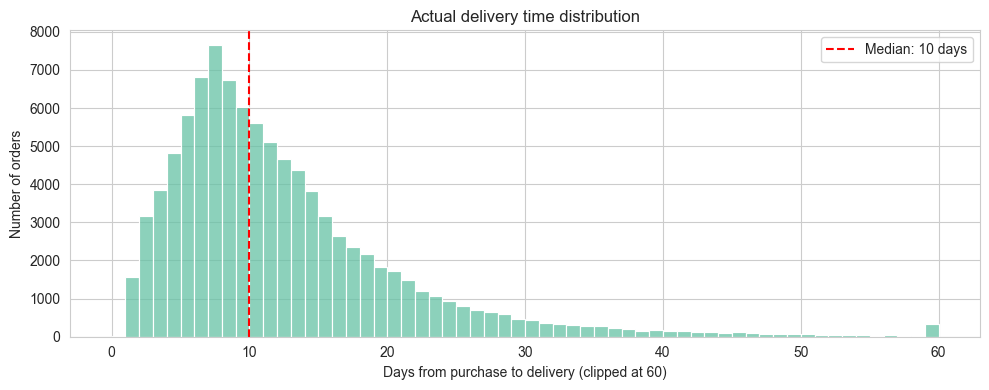

Median delivery time:   10 days
Mean delivery time:     12.1 days
95th percentile:        29 days
Max:                    209 days


In [4]:
# Per-order delivery time distribution (one row per delivered order).
delivery_days = (analysis_df.drop_duplicates("order_id")
                 .dropna(subset=["actual_delivery_days"])
                 ["actual_delivery_days"])

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(delivery_days.clip(0, 60), bins=60, ax=ax)
ax.set_xlabel("Days from purchase to delivery (clipped at 60)")
ax.set_ylabel("Number of orders")
ax.set_title("Actual delivery time distribution")
median_days = delivery_days.median()
ax.axvline(median_days, color="red", linestyle="--", label=f"Median: {median_days:.0f} days")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median delivery time:   {median_days:.0f} days")
print(f"Mean delivery time:     {delivery_days.mean():.1f} days")
print(f"95th percentile:        {delivery_days.quantile(0.95):.0f} days")
print(f"Max:                    {delivery_days.max():.0f} days")


**Delivery time distribution.** Median 10 days, mean 12.1 days, 95th percentile 29 days. The distribution is right-skewed with a long tail (max 209 days). The skew is the story: most orders arrive in a fortnight, but the worst-case tail extends to 6+ months. Day 2's hypotheses are about that tail, not the median.


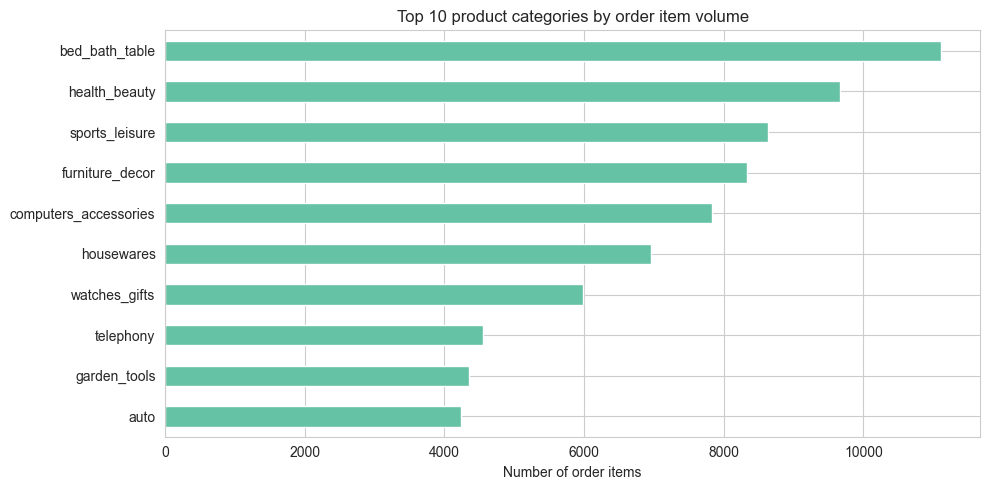

Top 10 categories cover 63.6% of all order items
Total distinct categories: 74


In [5]:
top_categories = (analysis_df
                  .groupby("category_en")
                  .size()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
top_categories.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of order items")
ax.set_ylabel("")
ax.set_title("Top 10 product categories by order item volume")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Top 10 categories cover {top_categories.sum() / len(analysis_df):.1%} of all order items")
print(f"Total distinct categories: {analysis_df['category_en'].nunique()}")


**Category mix.** 74 distinct categories, but the top 10 cover 63.6% of order items. Heavy concentration in `bed_bath_table`, `health_beauty`, `sports_leisure`, and `furniture_decor`. Any category-level finding will be dominated by these few categories.


## 2. Hypothesis test: promise gap vs category

**Methodology.** No statistics formalism, just groupby and means.

1. Define and visualise the promise gap.
2. Bucket orders into 5 delivery-timeliness groups (early 5+, early 1-4, on time, late 1-4, late 5+) and compute mean review per bucket. Look at the *range* from best bucket to worst.
3. Take the top-10 and bottom-10 categories by mean review and compute their range.
4. Compare ranges. Whichever is wider, that factor matters more.
5. Cross-check: among 1-star reviews vs 5-star reviews, what % were late deliveries?
6. Falsification test: take the bottom-5 categories by mean review and split each into on-time vs late. If on-time review scores in those categories are still bad (well below platform average), the category has its own quality issues independent of delivery, and H1 is partially false for those categories.


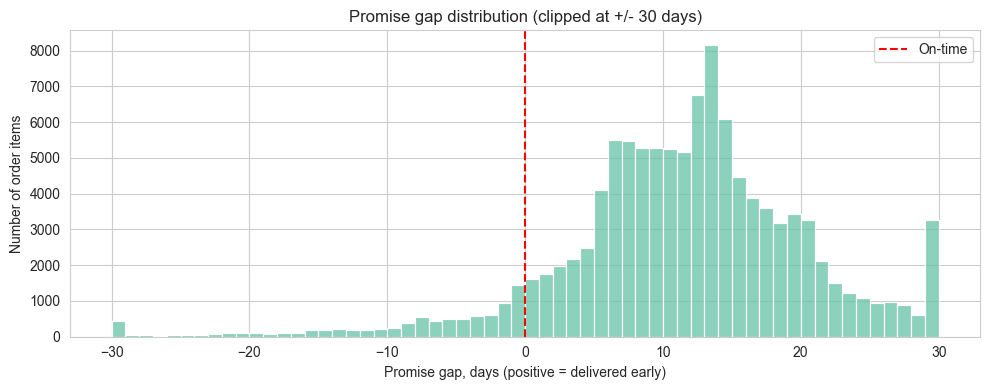

% delivered early (gap > 0):    90.6%
% delivered on the day (gap=0): 1.5%
% delivered late (gap < 0):     7.9%
Median gap: 12 days early


In [6]:
gap = analysis_df["promise_gap_days"].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(gap.clip(-30, 30), bins=60, ax=ax)
ax.axvline(0, color="red", linestyle="--", label="On-time")
ax.set_xlabel("Promise gap, days (positive = delivered early)")
ax.set_ylabel("Number of order items")
ax.set_title("Promise gap distribution (clipped at +/- 30 days)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"% delivered early (gap > 0):    {(gap > 0).mean():.1%}")
print(f"% delivered on the day (gap=0): {(gap == 0).mean():.1%}")
print(f"% delivered late (gap < 0):     {(gap < 0).mean():.1%}")
print(f"Median gap: {gap.median():.0f} days early")


**Promise gap distribution.** Olist is dramatically over-delivering on its promised dates. 90.6% of delivered orders arrive *early* (median 12 days early), only 7.9% arrive late, and 1.5% arrive on the day. Two implications. First, Olist's estimated delivery dates are conservative by design; they pad the quote so most deliveries beat it. Second, the 7.9% that *do* arrive late are interesting precisely because they are exceptions to a smooth-running pipeline. The hypothesis is that those late orders disproportionately drive bad reviews.


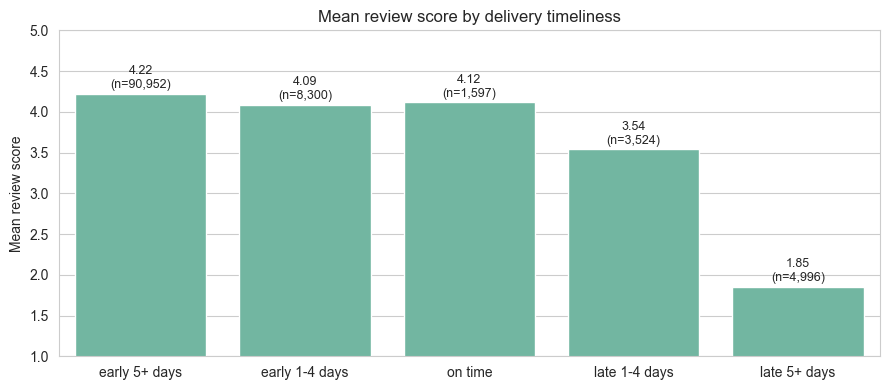


Mean review range across delivery buckets: 2.37 points
Best bucket:  early 5+ days (4.22)
Worst bucket: late 5+ days (1.85)


In [7]:
def gap_bucket(d):
    if pd.isna(d): return None
    if d >= 5:     return "early 5+ days"
    if d >= 1:     return "early 1-4 days"
    if d == 0:     return "on time"
    if d >= -4:    return "late 1-4 days"
    return "late 5+ days"

analysis_df["gap_bucket"] = analysis_df["promise_gap_days"].apply(gap_bucket)

bucket_order = ["early 5+ days", "early 1-4 days", "on time", "late 1-4 days", "late 5+ days"]
sub = analysis_df.dropna(subset=["gap_bucket", "review_score"])

review_by_bucket = (sub.groupby("gap_bucket")["review_score"]
                    .agg(mean_review="mean", n="count")
                    .reindex(bucket_order))

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=review_by_bucket.index, y=review_by_bucket["mean_review"], ax=ax)
ax.set_ylabel("Mean review score")
ax.set_xlabel("")
ax.set_title("Mean review score by delivery timeliness")
ax.set_ylim(1, 5)
for i, (bucket, row) in enumerate(review_by_bucket.iterrows()):
    ax.text(i, row["mean_review"] + 0.07,
            f"{row['mean_review']:.2f}\n(n={row['n']:,.0f})",
            ha="center", fontsize=9)
plt.tight_layout()
plt.show()

bucket_range = review_by_bucket["mean_review"].max() - review_by_bucket["mean_review"].min()
print(f"\nMean review range across delivery buckets: {bucket_range:.2f} points")
print(f"Best bucket:  {review_by_bucket['mean_review'].idxmax()} ({review_by_bucket['mean_review'].max():.2f})")
print(f"Worst bucket: {review_by_bucket['mean_review'].idxmin()} ({review_by_bucket['mean_review'].min():.2f})")


**Delivery timeliness drives a 2.37-point swing in mean review.** Orders delivered 5+ days early average 4.22 stars. Orders delivered 5+ days late average 1.85 stars, barely above the 1-star floor. The relationship is monotonic and roughly linear: each step of "lateness" knocks about 0.6 review points off the mean.


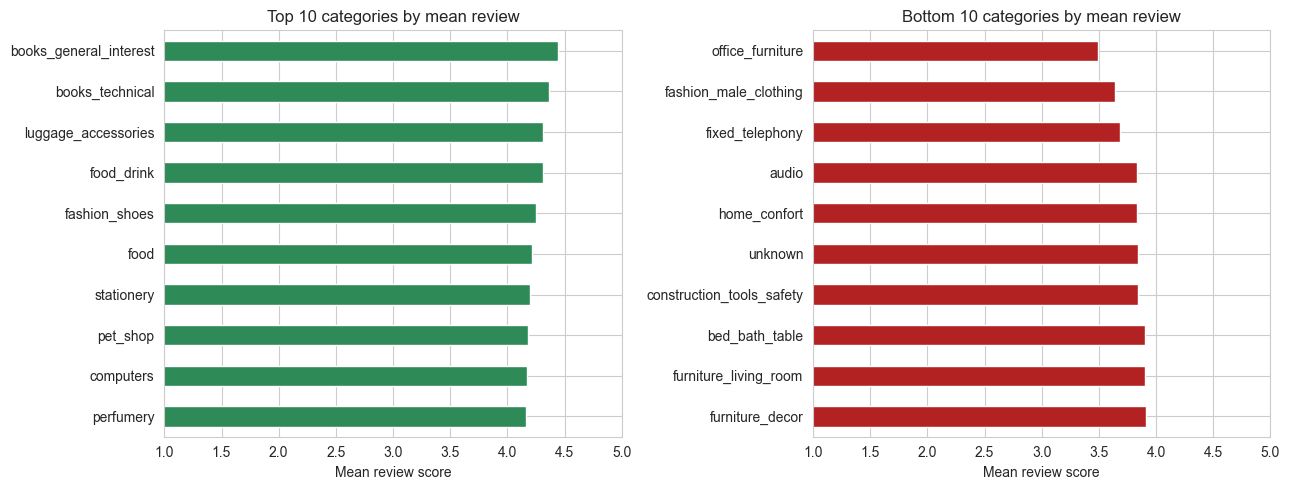


Mean review range across top-10 vs bottom-10 categories: 0.96 points
Best category:  books_general_interest (4.45)
Worst category: office_furniture (3.49)

--- Range comparison ---
Delivery timeliness range: 2.37 points
Category range:            0.96 points
Delivery range / category range = 2.48x


In [8]:
sub_cat = analysis_df.dropna(subset=["review_score", "category_en"]).copy()
cat_summary = (sub_cat.groupby("category_en")["review_score"]
               .agg(mean_review="mean", n="count")
               .query("n >= 100"))

top10 = cat_summary.nlargest(10, "mean_review")
bot10 = cat_summary.nsmallest(10, "mean_review")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top10["mean_review"].sort_values().plot(kind="barh", ax=axes[0], color="seagreen")
axes[0].set_xlim(1, 5)
axes[0].set_title("Top 10 categories by mean review")
axes[0].set_xlabel("Mean review score")
axes[0].set_ylabel("")

bot10["mean_review"].sort_values(ascending=False).plot(kind="barh", ax=axes[1], color="firebrick")
axes[1].set_xlim(1, 5)
axes[1].set_title("Bottom 10 categories by mean review")
axes[1].set_xlabel("Mean review score")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

cat_range = top10["mean_review"].max() - bot10["mean_review"].min()
print(f"\nMean review range across top-10 vs bottom-10 categories: {cat_range:.2f} points")
print(f"Best category:  {top10['mean_review'].idxmax()} ({top10['mean_review'].max():.2f})")
print(f"Worst category: {bot10['mean_review'].idxmin()} ({bot10['mean_review'].min():.2f})")

print(f"\n--- Range comparison ---")
print(f"Delivery timeliness range: {bucket_range:.2f} points")
print(f"Category range:            {cat_range:.2f} points")
print(f"Delivery range / category range = {bucket_range / cat_range:.2f}x")


**Category drives only a 0.96-point swing.** The best-rated category (`books_general_interest` at 4.45) and the worst-rated category (`office_furniture` at 3.49) differ by under 1 star. That is less than half the spread caused by delivery timeliness.

**Delivery timeliness drives 2.48x more variation in mean review than category does.** Customer satisfaction on Olist is fundamentally a logistics problem, not a product-mix problem.


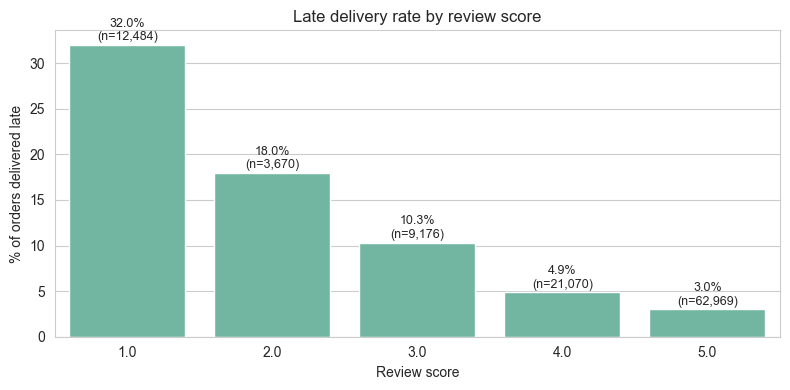


1-star reviews: 32.0% were late deliveries
5-star reviews: 3.0% were late deliveries
1-star reviews are 10.6x more likely to be late than 5-star reviews


In [9]:
sub_star = analysis_df.dropna(subset=["review_score", "promise_gap_days"]).copy()
sub_star["is_late"] = sub_star["promise_gap_days"] < 0

late_by_score = (sub_star.groupby("review_score")["is_late"]
                 .agg(pct_late="mean", n="count")
                 .reset_index())
late_by_score["pct_late_pct"] = late_by_score["pct_late"] * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x="review_score", y="pct_late_pct", data=late_by_score, ax=ax)
ax.set_xlabel("Review score")
ax.set_ylabel("% of orders delivered late")
ax.set_title("Late delivery rate by review score")
for i, row in late_by_score.iterrows():
    ax.text(i, row["pct_late_pct"] + 0.5,
            f"{row['pct_late_pct']:.1f}%\n(n={row['n']:,.0f})",
            ha="center", fontsize=9)
plt.tight_layout()
plt.show()

one_star_late = late_by_score.loc[late_by_score["review_score"] == 1, "pct_late_pct"].values[0]
five_star_late = late_by_score.loc[late_by_score["review_score"] == 5, "pct_late_pct"].values[0]
print(f"\n1-star reviews: {one_star_late:.1f}% were late deliveries")
print(f"5-star reviews: {five_star_late:.1f}% were late deliveries")
print(f"1-star reviews are {one_star_late / five_star_late:.1f}x more likely to be late than 5-star reviews")


**Late delivery is concentrated in 1-star reviews.** 32.0% of 1-star reviews were on orders delivered late. Only 3.0% of 5-star reviews were late. **1-star reviews are 10.6x more likely to be late than 5-star reviews.** Bad reviews come overwhelmingly from delivery failures; good reviews come overwhelmingly from on-time or early deliveries. This is the dramatic cut that the Day 3 Seller Trust Score will lean on.


In [10]:
# Bottom 5 categories by mean review (with sufficient volume to be meaningful).
bottom_5 = (sub_cat.groupby("category_en")["review_score"]
            .agg(mean_review="mean", n="count")
            .query("n >= 200")
            .nsmallest(5, "mean_review"))

# For each, mean review when delivered on-time-or-early vs delivered late.
fals_subset = sub_star[sub_star["category_en"].isin(bottom_5.index)].copy()
fals_subset["timeliness"] = np.where(fals_subset["promise_gap_days"] >= 0, "on_time_or_early", "late")

fals_data = (fals_subset.groupby(["category_en", "timeliness"])["review_score"]
             .mean()
             .unstack("timeliness"))

fals_n = (fals_subset.groupby(["category_en", "timeliness"])
          .size()
          .unstack("timeliness")
          .add_suffix("_n"))

fals = fals_data.join(fals_n).round(2)
fals["mean_review_overall"] = bottom_5["mean_review"].round(2)
fals = fals.loc[bottom_5.index]
fals


timeliness,late,on_time_or_early,late_n,on_time_or_early_n,mean_review_overall
category_en,,,,,
office_furniture,2.47,3.61,146,1508,3.49
fixed_telephony,2.20,3.82,10,242,3.68
audio,1.96,4.11,45,313,3.83
home_confort,2.50,4.01,44,383,3.84
unknown,2.38,4.10,141,1384,3.84


**Falsification result: H1 mostly holds, with one notable exception.** I took the 5 lowest-rated categories (with at least 200 reviews each) and split each into "delivered late" vs "delivered on-time-or-early". The on-time means look like this:

- `office_furniture`: 3.61 on-time vs 2.47 when late
- `fixed_telephony`: 3.82 vs 2.20
- `audio`: 4.11 vs 1.96
- `home_confort`: 4.01 vs 2.50
- `unknown`: 4.10 vs 2.38

For 4 of the 5 categories, on-time mean reviews jump back to roughly platform-average levels (3.8 to 4.1). H1 holds for those: the bad reviews were mostly caused by delivery failures, not inherent product issues.

**The exception is `office_furniture`**, which still averages 3.61 even when delivered on time. That is meaningfully below the platform-wide mean (around 4.0). For office_furniture sellers, the Day 3 Trust Score should account for a category-specific quality issue on top of delivery performance.
